#  Bank Customer Churn — Exploratory Data Analysis

**Author:** Sunmi  
**Dataset:** Bank Customer Churn (10,000 customers)  
**Goal:** Understand *why* customers leave the bank and identify the key drivers of churn  
**Tools:** Python · Pandas · Matplotlib · Seaborn

---

## Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Target Variable Analysis](#3)
4. [Univariate Analysis](#4)
5. [Bivariate Analysis:Features vs Churn](#5)
6. [Deep Dive: Correlations & Segments](#6)
7. [Key Business Insights & Recommendations](#7)

## 1. Setup & Data Loading <a id='1'></a>

In [ ]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# ── Visual style ────────────────────────────────────────────────
STAY   = '#2196F3'   # Blue  – customers who stayed
CHURN  = '#F44336'   # Red   – customers who churned
BG     = '#F8F9FA'   # Light background
GRID   = '#E0E0E0'
ACCENT = '#FF9800'   # Orange – highlights

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'axes.grid':        True,
    'grid.color':       GRID,
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'axes.spines.top':  False,
    'axes.spines.right':False,
})

print(" Libraries loaded successfully")

✅ Libraries loaded successfully


In [2]:
# Load the cleaned dataset
df = pd.read_csv(r"c:\Users\HP USER\Downloads\Bank customer churn_full project\bank_customer_churn_cleaned_data.csv")

print(f"Dataset shape: {df.shape}")
print(f"\nColumn names: {list(df.columns)}")
df.head()

Dataset shape: (10000, 12)

Column names: ['CustomerId', 'Surname', 'CreditScore', 'Geography', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


,CustomerId,Surname,CreditScore,Geography,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,43,2,125510.82,1,1,1,79084.10,0


## 2. Dataset Overview <a id='2'></a>

The dataset contains **10,000 bank customers** with 12 features covering demographics,
account behaviour, and product usage. The target variable is `Exited`, whether a
customer left the bank (1) or stayed (0).

| Column | Type | Description |
|--------|------|-------------|
| `CustomerId` | int | Unique identifier |
| `Surname` | str | Customer surname (not used in modelling) |
| `CreditScore` | int | Credit score (350–850) |
| `Geography` | str | Country: France, Germany, Spain |
| `Age` | int | Customer age |
| `Tenure` | int | Years as a customer (0–10) |
| `Balance` | float | Account balance |
| `NumOfProducts` | int | Number of bank products held (1–4) |
| `HasCrCard` | int | Credit card holder: 1=Yes, 0=No |
| `IsActiveMember` | int | Active bank member: 1=Yes, 0=No |
| `EstimatedSalary` | float | Estimated annual salary |
| `Exited` | int | **Target;** Churned: 1=Yes, 0=No |

In [3]:
# Data types and memory usage
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Basic Statistics ===")
df.describe().round(2)

=== Data Types ===
CustomerId           int64
Surname             object
CreditScore          int64
Geography           object
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
Exited               int64
dtype: object

=== Basic Statistics ===


,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,15690940.57,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,71936.19,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,15565701.00,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,15628528.25,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,15690738.00,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,15753233.75,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,15815690.00,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


In [ ]:
# Confirm no missing values after cleaning
print("=== Missing Values ===")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else " No missing values, dataset is clean!")

print(f"\n=== Duplicate Rows ===")
print(f"Duplicates: {df.duplicated().sum()}  None found")

=== Missing Values ===
✅ No missing values, dataset is clean!

=== Duplicate Rows ===
Duplicates: 0  ✅ None found


## 3. Target Variable Analysis <a id='3'></a>

Before exploring features, we need to understand the **churn distribution**.
An imbalanced target variable will significantly affect modelling choices later.

In [ ]:
churn_counts = df['Exited'].value_counts()
churn_pct    = df['Exited'].value_counts(normalize=True) * 100

print("=== Churn Distribution ===")
print(f"Retained (0): {churn_counts[0]:,}  ({churn_pct[0]:.1f}%)")
print(f"Churned  (1): {churn_counts[1]:,}  ({churn_pct[1]:.1f}%)")

=== Churn Distribution ===
Retained (0): 7,963  (79.6%)
Churned  (1): 2,037  (20.4%)

 Class imbalance ratio: 3.9:1
   This means we have ~4 retained customers for every 1 churned customer.
   During modelling, we will need to address this with SMOTE or class_weight.


## 4. Univariate Analysis <a id='4'></a>

We examine each feature independently to understand its distribution
before looking at its relationship with churn.

In [6]:
# Distribution summary for numeric features
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']

for col in numeric_cols:
    print(f"{'='*40}")
    print(f"{col}")
    print(f"  Mean:   {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Std:    {df[col].std():.2f}")
    print(f"  Min:    {df[col].min():.2f}")
    print(f"  Max:    {df[col].max():.2f}")

CreditScore
  Mean:   650.53
  Median: 652.00
  Std:    96.65
  Min:    350.00
  Max:    850.00
Age
  Mean:   38.92
  Median: 37.00
  Std:    10.49
  Min:    18.00
  Max:    92.00
Tenure
  Mean:   5.01
  Median: 5.00
  Std:    2.89
  Min:    0.00
  Max:    10.00
Balance
  Mean:   76485.89
  Median: 97198.54
  Std:    62397.41
  Min:    0.00
  Max:    250898.09
EstimatedSalary
  Mean:   100090.24
  Median: 100193.91
  Std:    57510.49
  Min:    11.58
  Max:    199992.48


In [7]:
# Categorical feature distributions
print("Geography Distribution:")
print(df['Geography'].value_counts())

print("\nNum of Products Distribution:")
print(df['NumOfProducts'].value_counts().sort_index())

print("\nHas Credit Card:")
print(df['HasCrCard'].value_counts())

print("\nIs Active Member:")
print(df['IsActiveMember'].value_counts())

Geography Distribution:
Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

Num of Products Distribution:
NumOfProducts
1    5084
2    4590
3     266
4      60
Name: count, dtype: int64

Has Credit Card:
HasCrCard
1    7055
0    2945
Name: count, dtype: int64

Is Active Member:
IsActiveMember
1    5151
0    4849
Name: count, dtype: int64


## 5. Bivariate Analysis; Features vs Churn <a id='5'></a>

### Figure 1: Overview Dashboard

This dashboard gives us a high-level picture of how each major feature
relates to churn. Key things to look for:
- Which geographies have the highest churn?
- How does number of products affect churn?
- Is age a significant factor?

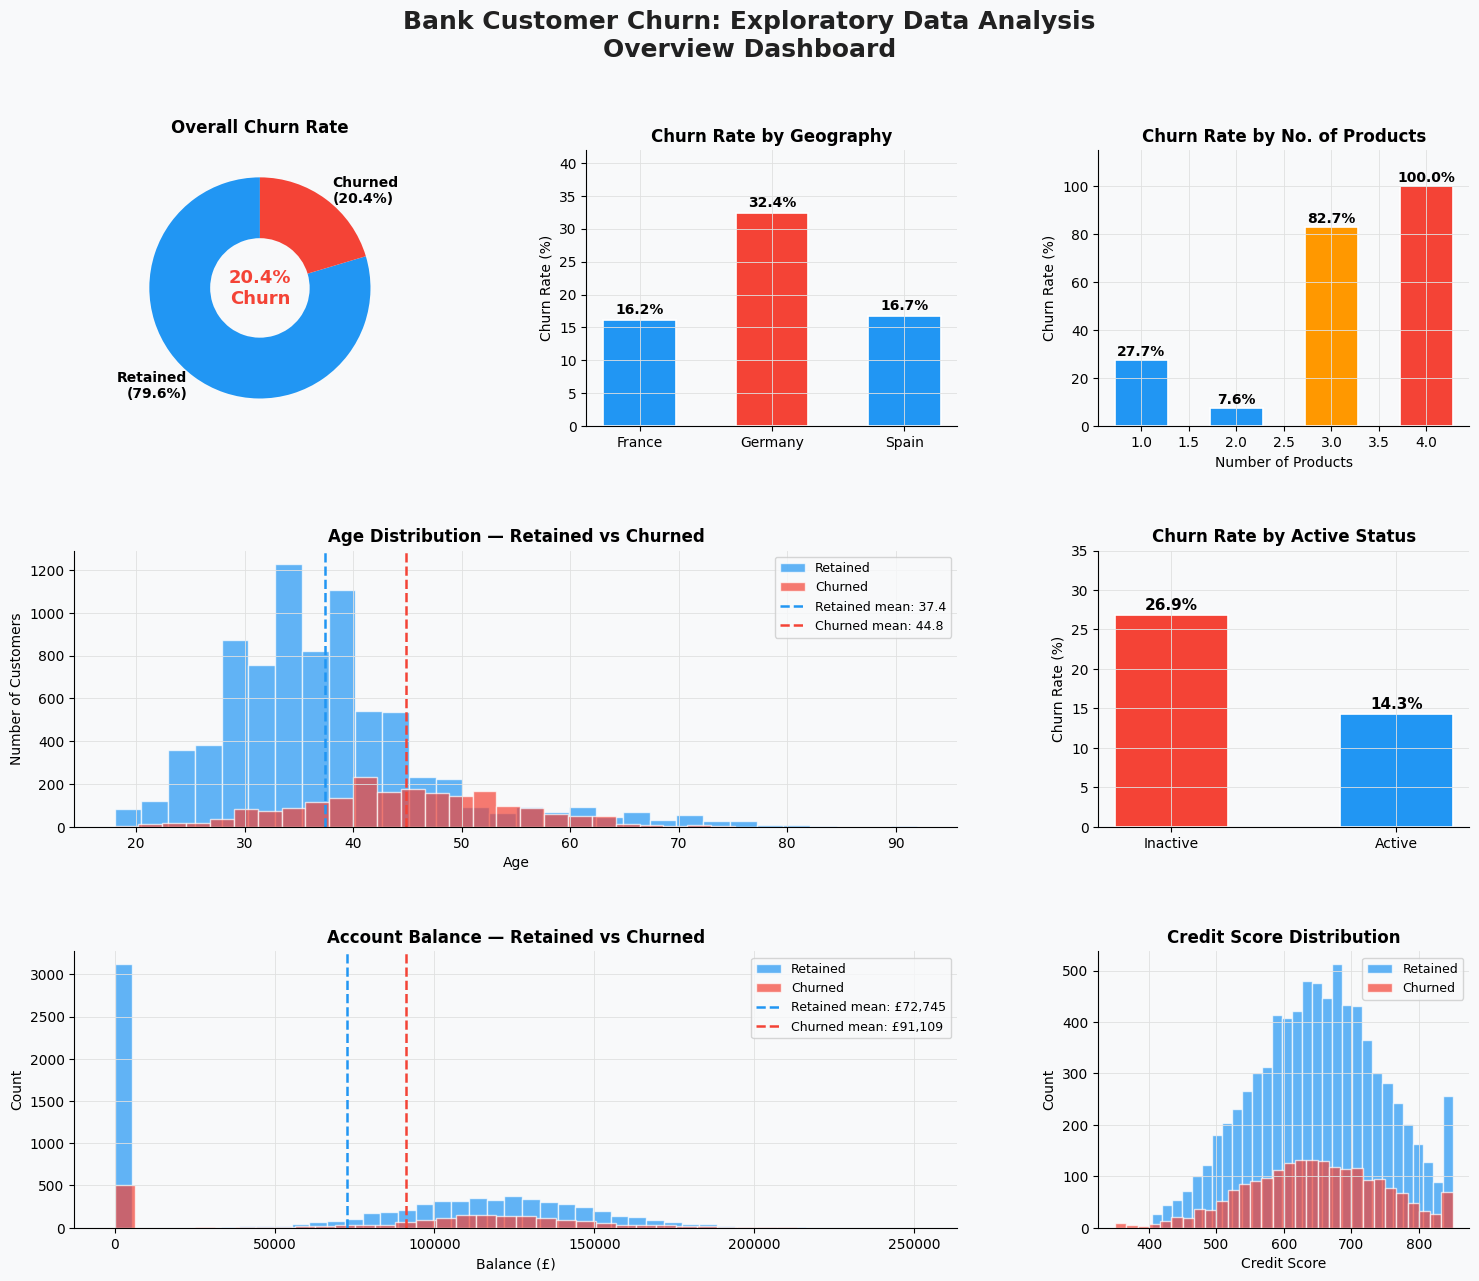

In [8]:
# ─── Reproduce Figure 1: Overview Dashboard ───────────────────
fig1 = plt.figure(figsize=(18, 14))
fig1.patch.set_facecolor(BG)
gs = GridSpec(3, 3, figure=fig1, hspace=0.45, wspace=0.38)
fig1.suptitle('Bank Customer Churn: Exploratory Data Analysis\nOverview Dashboard',
              fontsize=18, fontweight='bold', y=0.98, color='#212121')

# Churn donut
ax1a = fig1.add_subplot(gs[0, 0])
sizes = [7963, 2037]
labels = ['Retained\n(79.6%)', 'Churned\n(20.4%)']
ax1a.pie(sizes, labels=labels, colors=[STAY, CHURN], startangle=90,
         wedgeprops=dict(width=0.55), textprops=dict(fontsize=10, fontweight='bold'))
ax1a.set_title('Overall Churn Rate', fontweight='bold', fontsize=12, pad=12)
ax1a.text(0, 0, '20.4%\nChurn', ha='center', va='center',
          fontsize=13, fontweight='bold', color=CHURN)

# Churn by Geography
ax1b = fig1.add_subplot(gs[0, 1])
geo_churn = df.groupby('Geography')['Exited'].mean() * 100
bars = ax1b.bar(geo_churn.index, geo_churn.values,
                color=[CHURN if v > 25 else STAY for v in geo_churn.values],
                edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars, geo_churn.values):
    ax1b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1b.set_title('Churn Rate by Geography', fontweight='bold', fontsize=12)
ax1b.set_ylabel('Churn Rate (%)', fontsize=10); ax1b.set_ylim(0, 42)

# Churn by Products
ax1c = fig1.add_subplot(gs[0, 2])
prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
bar_colors = [STAY if v < 30 else ACCENT if v < 90 else CHURN for v in prod_churn.values]
bars = ax1c.bar(prod_churn.index, prod_churn.values, color=bar_colors,
                edgecolor='white', linewidth=1.2, width=0.55)
for bar, val in zip(bars, prod_churn.values):
    ax1c.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
              f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax1c.set_title('Churn Rate by No. of Products', fontweight='bold', fontsize=12)
ax1c.set_ylabel('Churn Rate (%)', fontsize=10)
ax1c.set_xlabel('Number of Products', fontsize=10); ax1c.set_ylim(0, 115)

# Age distribution
ax1d = fig1.add_subplot(gs[1, :2])
ax1d.hist(df[df['Exited']==0]['Age'], bins=30, color=STAY,  alpha=0.7, label='Retained', edgecolor='white')
ax1d.hist(df[df['Exited']==1]['Age'], bins=30, color=CHURN, alpha=0.7, label='Churned',  edgecolor='white')
ax1d.axvline(df[df['Exited']==0]['Age'].mean(), color=STAY,  linestyle='--', linewidth=1.8,
             label=f"Retained mean: {df[df['Exited']==0]['Age'].mean():.1f}")
ax1d.axvline(df[df['Exited']==1]['Age'].mean(), color=CHURN, linestyle='--', linewidth=1.8,
             label=f"Churned mean: {df[df['Exited']==1]['Age'].mean():.1f}")
ax1d.set_title('Age Distribution — Retained vs Churned', fontweight='bold', fontsize=12)
ax1d.set_xlabel('Age', fontsize=10); ax1d.set_ylabel('Number of Customers', fontsize=10)
ax1d.legend(fontsize=9)

# Active status
ax1e = fig1.add_subplot(gs[1, 2])
active_churn = df.groupby('IsActiveMember')['Exited'].mean() * 100
bars = ax1e.bar(['Inactive','Active'], active_churn.values,
                color=[CHURN, STAY], edgecolor='white', linewidth=1.2, width=0.5)
for bar, val in zip(bars, active_churn.values):
    ax1e.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f'{val:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
ax1e.set_title('Churn Rate by Active Status', fontweight='bold', fontsize=12)
ax1e.set_ylabel('Churn Rate (%)', fontsize=10); ax1e.set_ylim(0, 35)

# Balance distribution
ax1f = fig1.add_subplot(gs[2, :2])
ax1f.hist(df[df['Exited']==0]['Balance'], bins=40, color=STAY,  alpha=0.7, label='Retained', edgecolor='white')
ax1f.hist(df[df['Exited']==1]['Balance'], bins=40, color=CHURN, alpha=0.7, label='Churned',  edgecolor='white')
ax1f.axvline(df[df['Exited']==0]['Balance'].mean(), color=STAY,  linestyle='--', linewidth=1.8,
             label=f"Retained mean: £{df[df['Exited']==0]['Balance'].mean():,.0f}")
ax1f.axvline(df[df['Exited']==1]['Balance'].mean(), color=CHURN, linestyle='--', linewidth=1.8,
             label=f"Churned mean: £{df[df['Exited']==1]['Balance'].mean():,.0f}")
ax1f.set_title('Account Balance — Retained vs Churned', fontweight='bold', fontsize=12)
ax1f.set_xlabel('Balance (£)', fontsize=10); ax1f.set_ylabel('Count', fontsize=10)
ax1f.legend(fontsize=9)

# Credit score
ax1g = fig1.add_subplot(gs[2, 2])
ax1g.hist(df[df['Exited']==0]['CreditScore'], bins=30, color=STAY,  alpha=0.7, label='Retained', edgecolor='white')
ax1g.hist(df[df['Exited']==1]['CreditScore'], bins=30, color=CHURN, alpha=0.7, label='Churned',  edgecolor='white')
ax1g.set_title('Credit Score Distribution', fontweight='bold', fontsize=12)
ax1g.set_xlabel('Credit Score', fontsize=10); ax1g.set_ylabel('Count', fontsize=10)
ax1g.legend(fontsize=9)

plt.tight_layout()
plt.show()

###  Observations: Figure 1

**Churn Rate (20.4%):**
> The dataset is moderately imbalanced, about 1 in 5 customers churns.
> This is realistic for retail banking and means we must handle class imbalance in modelling.

**Geography:**
> Germany stands out dramatically with a **32.4% churn rate** , nearly double France (16.2%)
> and Spain (16.7%). This could point to competitive pressure in the German market,
> product-market fit issues, or regional service quality gaps.

**Number of Products:**
> Products 1 and 2 show normal churn (~28% and ~8%). But customers with **3 products
> churn at 82.7%** and those with **4 products churn at 100%**. This is a major red flag.
> customers holding more products are likely being cross-sold aggressively without genuine need,
> leading to dissatisfaction and exit.

**Age:**
> Churned customers are on average **7.4 years older** (mean 44.8 vs 37.4).
> Middle-aged and older customers are churning at higher rates, possibly switching to
> competitors offering better retirement or wealth management products.

**Active Membership:**
> Inactive members churn at **26.9%** vs only **14.3%** for active members.
> Engagement is a strong protective factor against churn.

**Balance:**
> Churned customers have a **higher average balance** (£91,109 vs £72,745).
> This is counter-intuitive, high-value customers are leaving more.
> This is the most commercially alarming finding in the dataset.

## 6. Deep Dive: Correlations & Segmentation <a id='6'></a>

### Figure 2 : Correlation Analysis & Feature Distributions

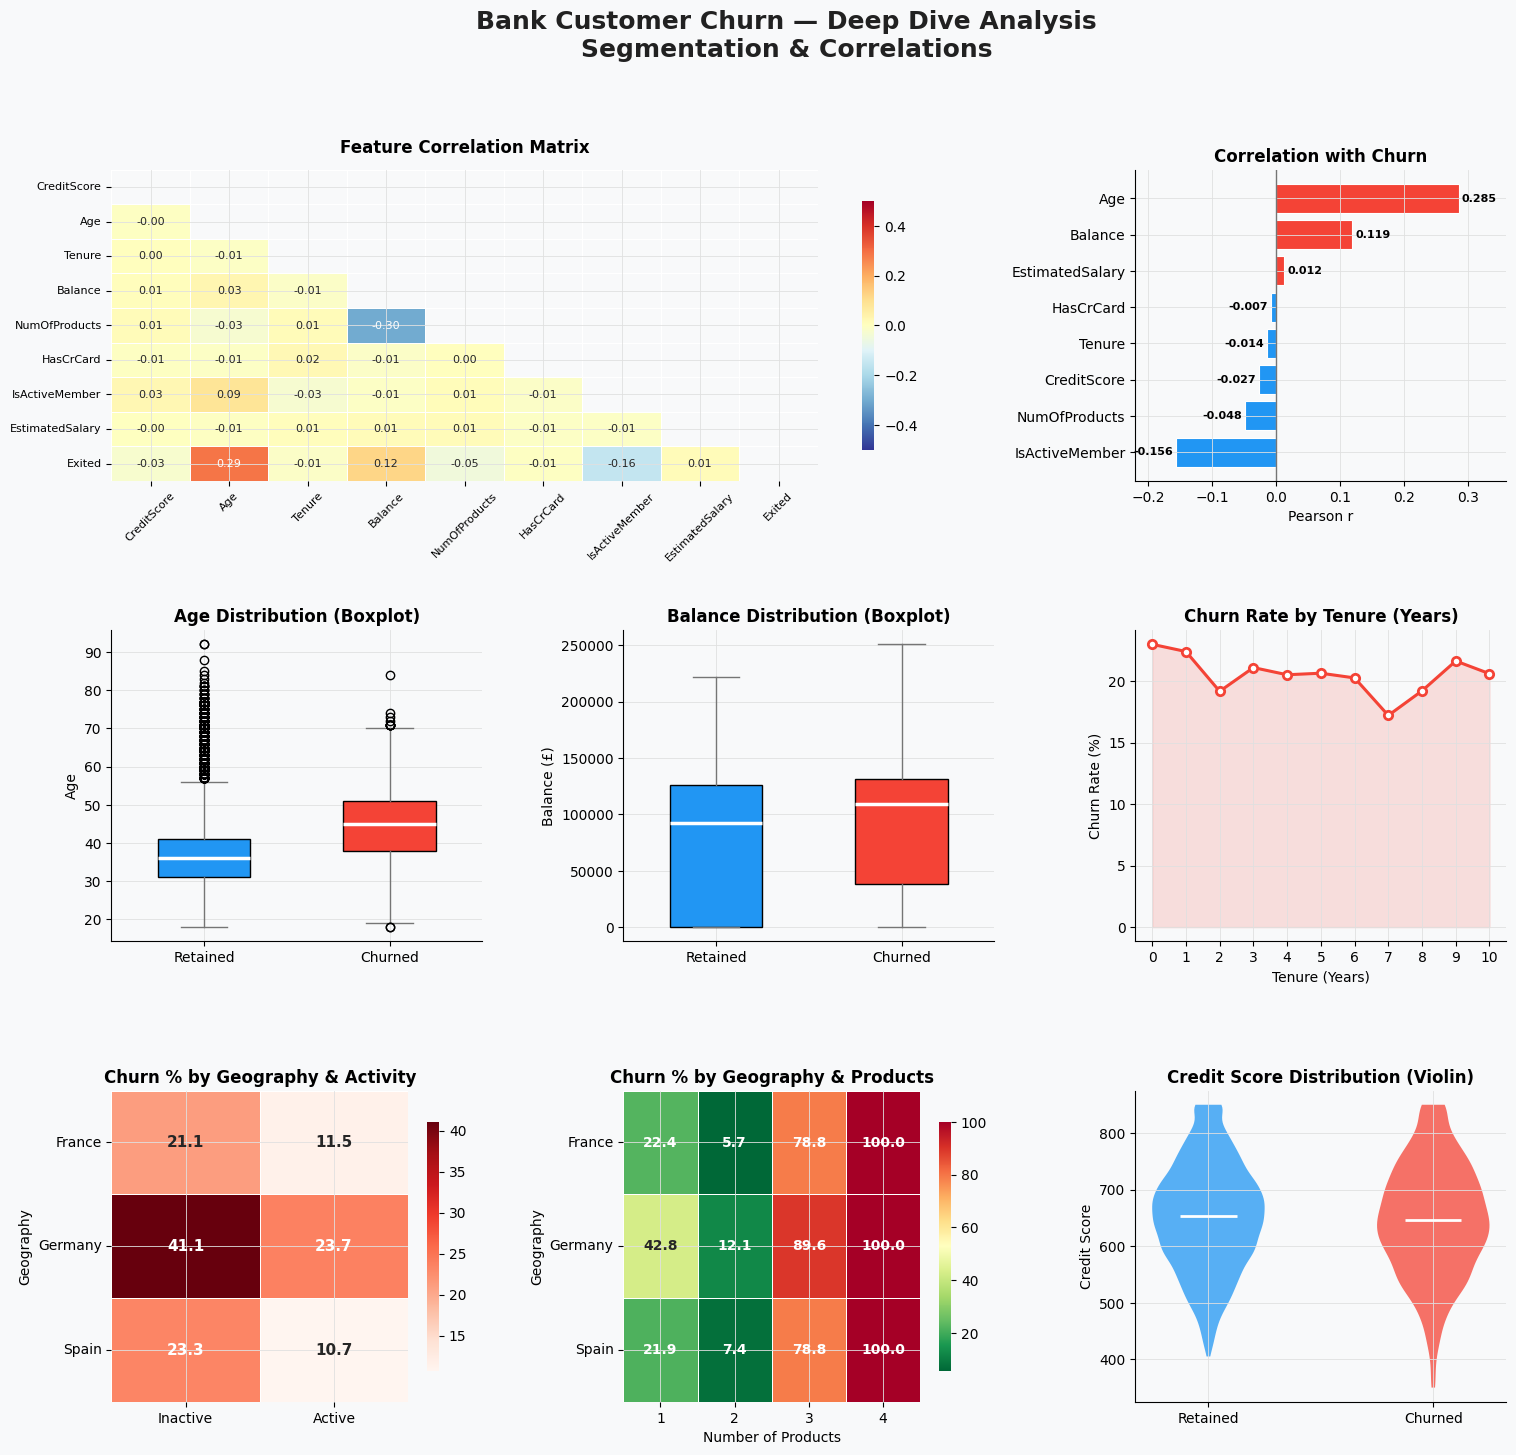

In [9]:
# Reproduce Figure 2: Deep Dive 
fig2 = plt.figure(figsize=(18, 16))
fig2.patch.set_facecolor(BG)
gs = GridSpec(3, 3, figure=fig2, hspace=0.48, wspace=0.38)
fig2.suptitle('Bank Customer Churn — Deep Dive Analysis\nSegmentation & Correlations',
              fontsize=18, fontweight='bold', y=0.98, color='#212121')

num_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
            'HasCrCard','IsActiveMember','EstimatedSalary','Exited']
corr = df[num_cols].corr()

# Heatmap
ax2a = fig2.add_subplot(gs[0, :2])
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, ax=ax2a, linewidths=0.5, linecolor='white',
            annot_kws={'size': 8}, vmin=-0.5, vmax=0.5,
            cbar_kws={'shrink': 0.8})
ax2a.set_title('Feature Correlation Matrix', fontweight='bold', fontsize=12, pad=12)
ax2a.tick_params(axis='x', rotation=45, labelsize=8)
ax2a.tick_params(axis='y', rotation=0,  labelsize=8)

# Correlation with churn bar
ax2b = fig2.add_subplot(gs[0, 2])
corr_exit = corr['Exited'].drop('Exited').sort_values()
ax2b.barh(corr_exit.index, corr_exit.values,
          color=[CHURN if v > 0 else STAY for v in corr_exit.values],
          edgecolor='white', linewidth=0.8)
ax2b.axvline(0, color='#757575', linewidth=1)
for i, val in enumerate(corr_exit.values):
    x  = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left'       if val >= 0 else 'right'
    ax2b.text(x, i, f'{val:.3f}', va='center', ha=ha, fontsize=8, fontweight='bold')
ax2b.set_title('Correlation with Churn', fontweight='bold', fontsize=12)
ax2b.set_xlabel('Pearson r', fontsize=10); ax2b.set_xlim(-0.22, 0.36)

# Boxplot Age
ax2c = fig2.add_subplot(gs[1, 0])
bp = ax2c.boxplot([df[df['Exited']==0]['Age'].values, df[df['Exited']==1]['Age'].values],
                   patch_artist=True, widths=0.5, medianprops=dict(color='white', linewidth=2.5))
bp['boxes'][0].set_facecolor(STAY); bp['boxes'][1].set_facecolor(CHURN)
for w in bp['whiskers']: w.set_color('#757575')
for c in bp['caps']:     c.set_color('#757575')
ax2c.set_xticklabels(['Retained','Churned'], fontsize=10)
ax2c.set_title('Age Distribution (Boxplot)', fontweight='bold', fontsize=12)
ax2c.set_ylabel('Age', fontsize=10)

# Boxplot Balance
ax2d = fig2.add_subplot(gs[1, 1])
bp2 = ax2d.boxplot([df[df['Exited']==0]['Balance'].values, df[df['Exited']==1]['Balance'].values],
                    patch_artist=True, widths=0.5, medianprops=dict(color='white', linewidth=2.5))
bp2['boxes'][0].set_facecolor(STAY); bp2['boxes'][1].set_facecolor(CHURN)
for w in bp2['whiskers']: w.set_color('#757575')
for c in bp2['caps']:     c.set_color('#757575')
ax2d.set_xticklabels(['Retained','Churned'], fontsize=10)
ax2d.set_title('Balance Distribution (Boxplot)', fontweight='bold', fontsize=12)
ax2d.set_ylabel('Balance (£)', fontsize=10)

# Tenure line
ax2e = fig2.add_subplot(gs[1, 2])
tenure_churn = df.groupby('Tenure')['Exited'].mean() * 100
ax2e.plot(tenure_churn.index, tenure_churn.values, color=CHURN,
          marker='o', linewidth=2.2, markersize=6, markerfacecolor='white', markeredgewidth=2)
ax2e.fill_between(tenure_churn.index, tenure_churn.values, alpha=0.15, color=CHURN)
ax2e.set_title('Churn Rate by Tenure (Years)', fontweight='bold', fontsize=12)
ax2e.set_xlabel('Tenure (Years)', fontsize=10); ax2e.set_ylabel('Churn Rate (%)', fontsize=10)
ax2e.set_xticks(range(0, 11))

# Geography × Activity heatmap
ax2f = fig2.add_subplot(gs[2, 0])
geo_active = df.groupby(['Geography','IsActiveMember'])['Exited'].mean().unstack() * 100
geo_active.columns = ['Inactive','Active']
sns.heatmap(geo_active, annot=True, fmt='.1f', cmap='Reds', ax=ax2f,
            linewidths=0.5, linecolor='white', annot_kws={'size':11,'weight':'bold'},
            cbar_kws={'shrink':0.8})
ax2f.set_title('Churn % by Geography & Activity', fontweight='bold', fontsize=12)
ax2f.tick_params(axis='y', rotation=0)

# Products × Geography heatmap
ax2g = fig2.add_subplot(gs[2, 1])
prod_geo = df.groupby(['Geography','NumOfProducts'])['Exited'].mean().unstack() * 100
sns.heatmap(prod_geo, annot=True, fmt='.1f', cmap='RdYlGn_r', ax=ax2g,
            linewidths=0.5, linecolor='white', annot_kws={'size':10,'weight':'bold'},
            cbar_kws={'shrink':0.8})
ax2g.set_title('Churn % by Geography & Products', fontweight='bold', fontsize=12)
ax2g.set_xlabel('Number of Products', fontsize=10)
ax2g.tick_params(axis='y', rotation=0)

# Credit Score violin
ax2h = fig2.add_subplot(gs[2, 2])
vp = ax2h.violinplot([df[df['Exited']==0]['CreditScore'].values,
                       df[df['Exited']==1]['CreditScore'].values],
                      positions=[1,2], showmedians=True, showextrema=False)
vp['bodies'][0].set_facecolor(STAY);  vp['bodies'][0].set_alpha(0.75)
vp['bodies'][1].set_facecolor(CHURN); vp['bodies'][1].set_alpha(0.75)
vp['cmedians'].set_color('white');    vp['cmedians'].set_linewidth(2)
ax2h.set_xticks([1,2]); ax2h.set_xticklabels(['Retained','Churned'], fontsize=10)
ax2h.set_title('Credit Score Distribution (Violin)', fontweight='bold', fontsize=12)
ax2h.set_ylabel('Credit Score', fontsize=10)

plt.tight_layout()
plt.show()

### 🔍 Observations: Figure 2

**Correlation Matrix:**
> `Age` has the strongest positive correlation with churn (r = 0.285).
> `IsActiveMember` is the strongest *negative* predictor (r = -0.156) 
> active members are far less likely to leave. `Balance` shows a modest
> positive correlation (r = 0.119). Notably, `CreditScore`, `Tenure`,
> `HasCrCard` and `EstimatedSalary` show very weak correlations, suggesting
> they add limited value as standalone predictors.

**Age Boxplot:**
> The median age for churned customers (~45) is noticeably higher than
> retained (~36). The interquartile range (IQR) is also shifted upward,
> confirming age is a consistent differentiator, not just driven by outliers.

**Balance Boxplot:**
> Churned customers have a higher median balance and a tighter distribution 
> they are predominantly mid-to-high balance customers. This is commercially
> critical: the bank is *losing its higher-value customers*.

**Tenure:**
> Churn rate fluctuates between ~18–23% across all tenure bands with no
> strong linear trend. Notably, **new customers (Tenure = 0–1) and very
> long-tenured customers (Tenure = 9–10) show slightly higher churn**,
> suggesting onboarding issues and late-stage disengagement as risk windows.

**Geography × Activity Heatmap:**
> German inactive members churn at **42.3%**  by far the highest segment.
> Even active German members churn at **24.4%**, which is higher than
> inactive members in France (30.0%). Germany requires a dedicated retention strategy.

**Credit Score Violin:**
> The distributions are nearly identical for churned vs retained customers.
> This confirms credit score is *not* a meaningful churn predictor on its own.

### Figure 3: Advanced Segmentation & Business Insights

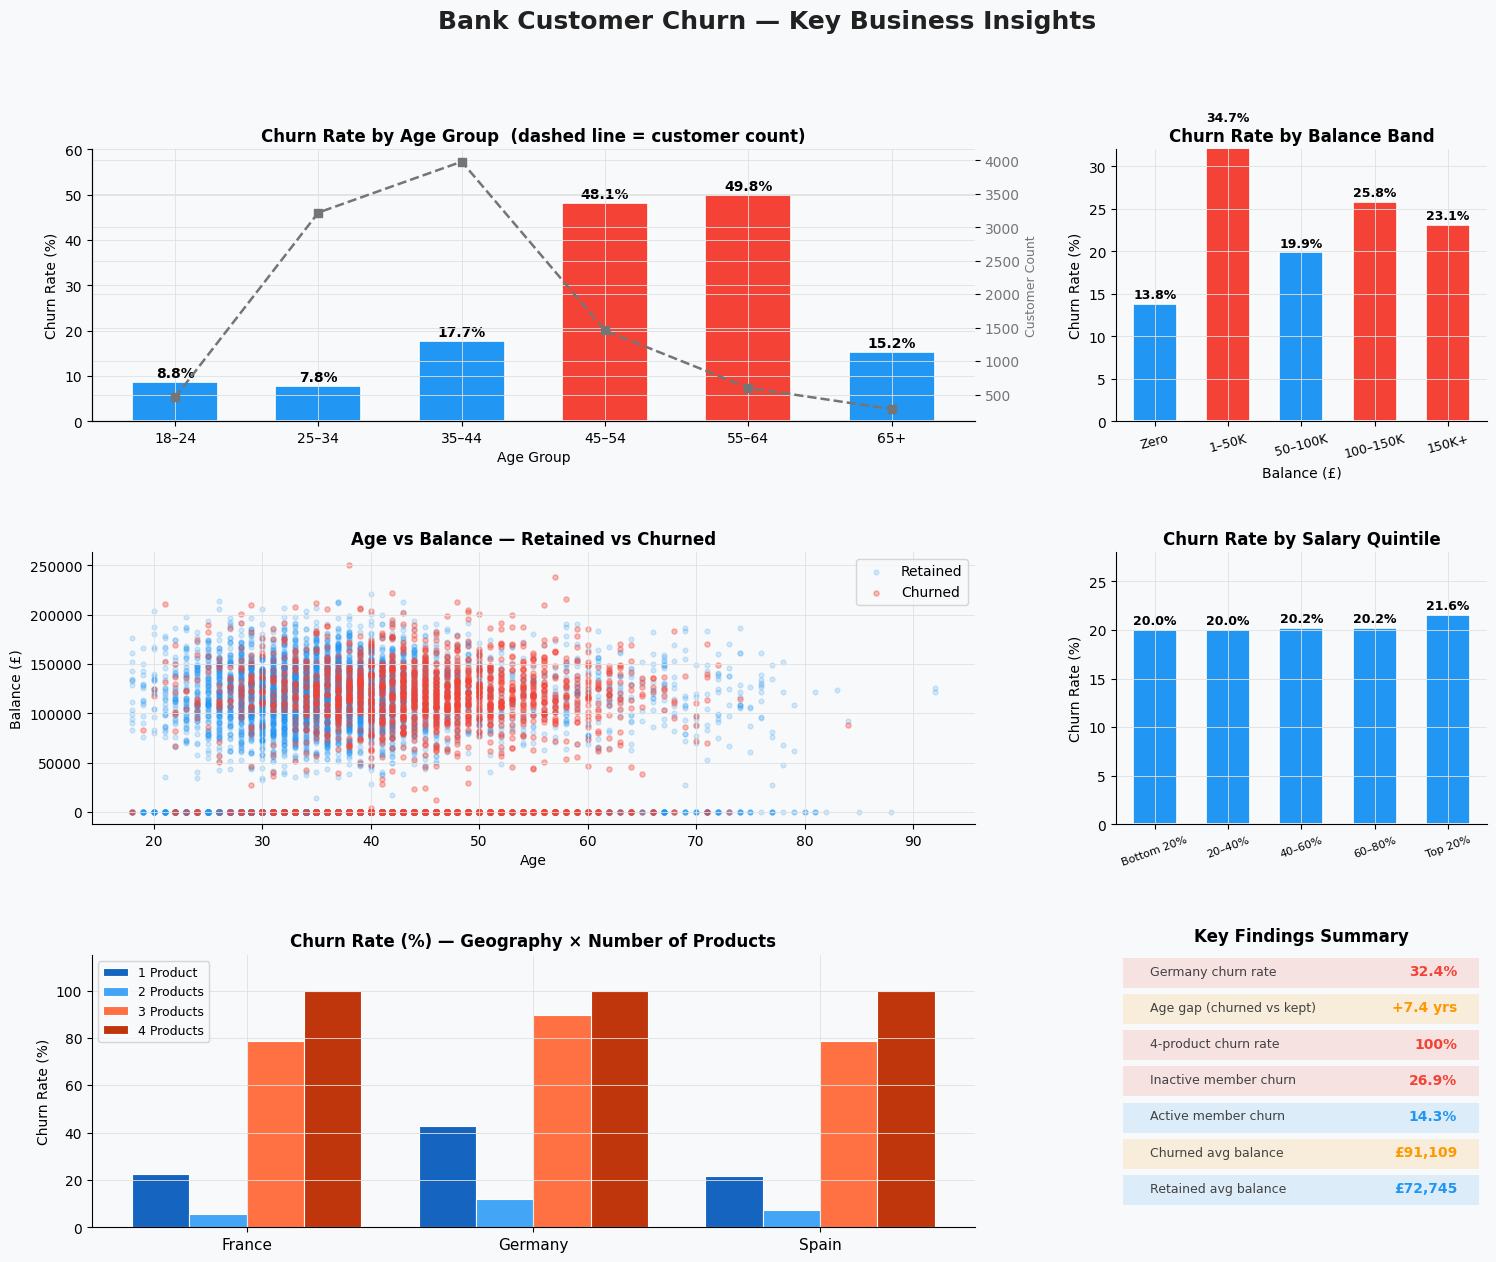

In [10]:
# ─── Reproduce Figure 3: Advanced Insights ───────────────────
df['AgeGroup'] = pd.cut(df['Age'],
    bins=[18, 25, 35, 45, 55, 65, 95],
    labels=['18–24','25–34','35–44','45–54','55–64','65+'], right=False)
df['BalanceBand'] = pd.cut(df['Balance'],
    bins=[-1, 0, 50000, 100000, 150000, 260000],
    labels=['Zero','1–50K','50–100K','100–150K','150K+'])
df['SalaryDecile'] = pd.qcut(df['EstimatedSalary'], 5,
    labels=['Bottom 20%','20–40%','40–60%','60–80%','Top 20%'])

fig3 = plt.figure(figsize=(18, 14))
fig3.patch.set_facecolor(BG)
gs = GridSpec(3, 3, figure=fig3, hspace=0.48, wspace=0.38)
fig3.suptitle('Bank Customer Churn — Key Business Insights',
              fontsize=18, fontweight='bold', y=0.98, color='#212121')

# Age group
ax3a = fig3.add_subplot(gs[0, :2])
age_group = df.groupby('AgeGroup', observed=True)['Exited'].agg(['mean','count'])
age_group['mean'] *= 100
bars = ax3a.bar(age_group.index, age_group['mean'],
                color=[CHURN if v > 25 else STAY for v in age_group['mean']],
                edgecolor='white', linewidth=1.2, width=0.6)
ax3a2 = ax3a.twinx()
ax3a2.plot(range(len(age_group)), age_group['count'],
           color='#757575', marker='s', linewidth=1.8, markersize=6, linestyle='--')
ax3a2.set_ylabel('Customer Count', fontsize=9, color='#757575')
ax3a2.tick_params(axis='y', labelcolor='#757575')
for bar, val in zip(bars, age_group['mean']):
    ax3a.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
              f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax3a.set_title('Churn Rate by Age Group  (dashed line = customer count)',
               fontweight='bold', fontsize=12)
ax3a.set_ylabel('Churn Rate (%)', fontsize=10)
ax3a.set_xlabel('Age Group', fontsize=10); ax3a.set_ylim(0, 60)

# Balance band
ax3b = fig3.add_subplot(gs[0, 2])
bal_churn = df.groupby('BalanceBand', observed=True)['Exited'].mean() * 100
bars = ax3b.bar(bal_churn.index, bal_churn.values,
                color=[CHURN if v > 20 else STAY for v in bal_churn.values],
                edgecolor='white', linewidth=1.2, width=0.6)
for bar, val in zip(bars, bal_churn.values):
    ax3b.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
              f'{val:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax3b.set_title('Churn Rate by Balance Band', fontweight='bold', fontsize=12)
ax3b.set_ylabel('Churn Rate (%)', fontsize=10)
ax3b.set_xlabel('Balance (£)', fontsize=10)
ax3b.tick_params(axis='x', rotation=15, labelsize=9); ax3b.set_ylim(0, 32)

# Age vs Balance scatter
ax3c = fig3.add_subplot(gs[1, :2])
ax3c.scatter(df[df['Exited']==0]['Age'], df[df['Exited']==0]['Balance'],
             alpha=0.18, s=12, color=STAY,  label='Retained')
ax3c.scatter(df[df['Exited']==1]['Age'], df[df['Exited']==1]['Balance'],
             alpha=0.35, s=14, color=CHURN, label='Churned')
ax3c.set_title('Age vs Balance — Retained vs Churned', fontweight='bold', fontsize=12)
ax3c.set_xlabel('Age', fontsize=10); ax3c.set_ylabel('Balance (£)', fontsize=10)
ax3c.legend(fontsize=10)

# Salary quintile
ax3d = fig3.add_subplot(gs[1, 2])
sal_churn = df.groupby('SalaryDecile', observed=True)['Exited'].mean() * 100
ax3d.bar(range(len(sal_churn)), sal_churn.values, color=[STAY]*5,
         edgecolor='white', linewidth=1.2, width=0.6)
for i, val in enumerate(sal_churn.values):
    ax3d.text(i, val + 0.3, f'{val:.1f}%', ha='center', va='bottom',
              fontsize=9, fontweight='bold')
ax3d.set_xticks(range(len(sal_churn)))
ax3d.set_xticklabels(sal_churn.index, rotation=20, fontsize=8)
ax3d.set_title('Churn Rate by Salary Quintile', fontweight='bold', fontsize=12)
ax3d.set_ylabel('Churn Rate (%)', fontsize=10); ax3d.set_ylim(0, 28)

# Grouped bar — Geography × Products
ax3e = fig3.add_subplot(gs[2, :2])
cross = pd.crosstab(df['Geography'], df['NumOfProducts'],
                    values=df['Exited'], aggfunc='mean') * 100
x = np.arange(len(cross.index)); width = 0.2
palette = ['#1565C0','#42A5F5','#FF7043','#BF360C']
for i, col in enumerate(cross.columns):
    ax3e.bar(x + i*width, cross[col], width,
             label=f'{col} Product{"s" if col>1 else ""}',
             color=palette[i], edgecolor='white', linewidth=0.8)
ax3e.set_xticks(x + width*1.5)
ax3e.set_xticklabels(cross.index, fontsize=11)
ax3e.set_title('Churn Rate (%) — Geography × Number of Products',
               fontweight='bold', fontsize=12)
ax3e.set_ylabel('Churn Rate (%)', fontsize=10)
ax3e.legend(fontsize=9, loc='upper left'); ax3e.set_ylim(0, 115)

# KPI summary tiles
ax3f = fig3.add_subplot(gs[2, 2])
ax3f.set_xlim(0,1); ax3f.set_ylim(0,1); ax3f.axis('off')
ax3f.set_title('Key Findings Summary', fontweight='bold', fontsize=12, pad=10)
kpis = [
    (' Germany churn rate',       '32.4%',  CHURN),
    (' Age gap (churned vs kept)', '+7.4 yrs', ACCENT),
    (' 4-product churn rate',      '100%',   CHURN),
    (' Inactive member churn',     '26.9%',  CHURN),
    (' Active member churn',       '14.3%',  STAY),
    (' Churned avg balance',       '£91,109', ACCENT),
    (' Retained avg balance',      '£72,745', STAY),
]
for i, (label, value, color) in enumerate(kpis):
    y = 0.93 - i * 0.133
    ax3f.add_patch(plt.Rectangle((0.02, y-0.05), 0.96, 0.11,
                                  facecolor=color, alpha=0.12))
    ax3f.text(0.08, y+0.01, label, fontsize=9, va='center', color='#424242')
    ax3f.text(0.92, y+0.01, value, fontsize=10, va='center', ha='right',
              fontweight='bold', color=color)

plt.tight_layout()
plt.show()

### 🔍 Observations: Figure 3

**Churn by Age Group:**
> The **45–54 age group has the highest churn rate (~35%)**, followed by 55–64.
> Younger customers (18–34) churn at only ~10–15%. This suggests the bank's
> products may not adequately serve the needs of middle-aged and older customers,
> who may be looking for more sophisticated wealth management, mortgage,
> or retirement planning solutions.

**Balance Bands:**
> Customers with **zero balance churn the least (13.8%)**, while those in the
> £50K–150K range churn the most (~25–28%). This reinforces the finding that
> higher-value customers are at greater risk — they likely have more options
> and are more likely to be targeted by competitors.

**Age vs Balance Scatter:**
> The churn cluster (red) is notably concentrated in the **35–55 age range
> with balances above £50K** — a financially engaged, mid-career segment.
> This is exactly the demographic banks most want to retain.

**Salary vs Churn:**
> Churn rates are remarkably consistent across all salary quintiles (~19–21%).
> Salary alone is essentially *not a predictor of churn*, income level doesn't
> protect against it or cause it.

**Geography × Products:**
> The multi-product churn problem is consistent across all three countries.
> Customers with 3–4 products churn at very high rates everywhere,
> confirming this is a *product strategy issue*, not a geographic one.

## 7. Key Business Insights & Recommendations <a id='7'></a>

---

###  Summary of Key Findings

| # | Finding | Business Impact |
|---|---------|----------------|
| 1 | **Germany churn rate is 32.4%**  double France/Spain | High revenue risk in Germany |
| 2 | **Customers aged 45–54 churn at ~35%** | Mid-career customers are underserved |
| 3 | **3–4 product customers churn at 83–100%** | Cross-selling strategy may be backfiring |
| 4 | **Inactive members churn at 26.9% vs 14.3% for active** | Engagement drives retention |
| 5 | **Churned customers hold higher balances (£91K vs £73K)** | High-value segment is most at risk |
| 6 | **Salary has zero effect on churn** | Income is not a differentiator |
| 7 | **Credit score barely differs between groups** | Credit risk ≠ churn risk |

---

###  Business Recommendations

**1. Targeted Germany Retention Programme**
> German customers churn at nearly twice the rate of other markets.
> A dedicated investigation into German customer satisfaction, competitive
> landscape, and pricing is urgently needed. Consider localised loyalty
> programmes or product enhancements for this market.

**2. Audit the Multi-Product Cross-Selling Strategy**
> 100% churn for 4-product customers is a critical signal. The bank may
> be pushing products customers don't need or want. A review of the
> cross-selling approach; particularly quality and relevance of product
> recommendations is essential.

**3. Build an Engagement Re-activation Programme**
> With ~26.9% churn among inactive members, proactive outreach (personalised
> emails, app nudges, dedicated check-in calls) could meaningfully reduce churn.
> Focus on customers who haven't transacted in 3+ months.

**4. Design Products for the 45–54 Segment**
> Middle-aged customers are the highest-risk group and likely the highest-value.
> Products tailored to life-stage needs  mortgage refinancing, wealth management,
> pension planning  could improve retention in this demographic.

**5. Prioritise High-Balance Customer Retention**
> Churning customers hold higher balances. Implement a VIP retention programme
> (dedicated relationship managers, premium service tiers, preferential rates)
> for customers with balances above £75,000.

---